# Pricer project — Day 1 (fixed)

This notebook fixes the errors found in the original script:

1. `test_item` could be `None` (the crash you hit) — now handled safely.
2. `datasets` force-reinstall now happens **before** it's imported, with a reminder to restart the runtime.
3. `SIZE` is now clamped to however many items actually exist after dedup, so `np.random.choice` can't ask for more items than exist.
4. The weight-vs-price scatter plot now filters out items with no weight instead of crashing.
5. Train/val/test split sizes are now computed from the actual sample size instead of hardcoded numbers.
6. The Hugging Face `push_to_hub` username is called out clearly — put **your own** HF username there.

> Run the cells top to bottom. After the "reinstall datasets" cell, restart the runtime once (Colab will usually prompt you), then continue running the remaining cells.

In [ ]:
# STEP 1 — pin the datasets version BEFORE it gets imported anywhere else.
# Doing this first (instead of after importing `datasets`) avoids the classic
# Colab gotcha where a force-reinstalled package doesn't take effect until
# the Python process is restarted, because the old module stays cached.
%pip install -q --force-reinstall "datasets==3.6.0"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.2 which is incompatible.


**⚠️ Now restart the runtime** (Runtime → Restart session) before running the cells below, so the pinned `datasets` version is actually loaded.

In [ ]:
import zipfile

zip_path = "/content/LLM_Engineering_opensource-main.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
import os
import sys
import random

import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
from tqdm.notebook import tqdm

# Add local project package to the path
sys.path.append(
    "/content/LLM_Engineering_opensource-main/finetuning_local_frontier_models/"
)

from pricer.items import Item
from pricer.evaluator import *

load_dotenv(override=True)

import datasets
print("datasets version:", datasets.__version__)  # should now print 3.6.0

datasets version: 3.6.0


In [ ]:
# Optional — sanity-check that the pricer package files are where we expect
!find "/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer" -maxdepth 2 -type f -print
!ls -la "/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer"

/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/batch.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/parser.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/items.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/loaders.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/evaluator.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/preprocessor.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/deep_neural_network.py
total 48
drwxr-xr-x 2 root root 4096 Aug 23 07:02 .
drwxr-xr-x 3 root root 4096 Aug 23 07:02 ..
-rw-r--r-- 1 root root 4810 Aug 23 07:10 batch.py
-rw-r--r-- 1 root root 6433 Aug 23 07:10 deep_neural_network.py
-rw-r--r-- 1 root root 7028 Aug 23 07:10 evaluator.py
-rw-r--r-- 1 root root 1718 Aug 23 07:10 items.py
-rw-r--r-- 1 root root 2485 Aug 23 07:10 loaders.py
-rw-r--r-- 1 root root 24

In [ ]:
# Log in to HuggingFace - if you get a "Note" about Environment variable being set, ignore it
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(hf_token, add_to_git_credential=True)

print("Hugging Face login successful!")

Hugging Face login successful!


In [ ]:
dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Appliances",
    split="full",
    trust_remote_code=True
)

print(dataset)
print(f"Number of Appliances: {len(dataset):,}")

raw/meta_categories/meta_Appliances.json(…): reconstructing file:   0%|          |  0.00B /  285MB            

raw/meta_categories/meta_Appliances.json(…): downloading bytes:           |  0.00B            

Generating full split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author'],
    num_rows: 94327
})
Number of Appliances: 94,327


In [ ]:
# Investigate a particular datapoint
print(dataset[6])

{'main_category': 'Appliances', 'title': 'WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003', 'average_rating': 4.6, 'rating_number': 323, 'features': ['【PARTS NUMBER】The WD12X10327 dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF APPLICATION】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【REPLACES PART】1811003, AP4980629, WD12X0330, WD12X0356, WD12X0357, WD12X0383, WD12X0385, WD12X10327, WD12X330, WD12X356, WD12X357, WD12X383, WD12X385', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a repla

In [ ]:
# What's the most expensive item?
max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except (ValueError, TypeError):
        pass

if max_item is not None:
    print(f"The most expensive item is {max_item['title']} and it costs {max_price:,.2f}")
else:
    print("No item in this dataset had a valid price.")

  0%|          | 0/94327 [00:00<?, ?it/s]

The most expensive item is TurboChef BULLET Rapid Cook Electric Microwave Convection Oven and it costs 21,095.62


In [ ]:
# Optional — inspect the pricer source for reference
!grep -RniE "def parse|class Item|def .*item|price.*1000" \
"/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer"
!cat "/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/items.py"
!cat "/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/evaluator.py"

/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/batch.py:30:    def __init__(self, items, start, end, lite):
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/batch.py:45:    def make_jsonl(self, item):
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/batch.py:106:    def create(cls, items, lite):
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/batch.py:143:    def load(cls, items):
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/parser.py:72:def parse(datapoint, category):
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/items.py:10:class Item(BaseModel):
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/loaders.py:14:class ItemLoader:
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/deep_neural_network.py:167:    def inference(self, item):
from pydantic import BaseModel
from datasets im

In [ ]:
import re
import ast

def parse(datapoint, category):
    try:
        # Price must exist and be between $1 and $1000
        price = float(datapoint["price"])

        if price < 1 or price > 1000:
            return None

        # Product title
        title = datapoint.get("title")

        if not title or not isinstance(title, str):
            return None

        # Description
        description = datapoint.get("description")

        # Features
        features = datapoint.get("features")

        # Convert features into readable text
        if isinstance(features, list):
            features_text = " ".join(str(x) for x in features)
        else:
            features_text = str(features) if features else ""

        # Convert description into readable text
        if isinstance(description, list):
            description_text = " ".join(str(x) for x in description)
        else:
            description_text = str(description) if description else ""

        # Build the full product information
        full = f"{title}. {features_text}. {description_text}".strip()

        # Remove excessive whitespace
        full = re.sub(r"\s+", " ", full)

        # Require enough product information
        if len(full) < 20:
            return None

        # Create Item
        item = Item(
            title=title,
            category=category,
            price=price,
            full=full,
            summary=full
        )

        return item

    except (ValueError, TypeError, KeyError):
        return None

In [ ]:
# FIX: dataset[0] on its own can easily fail parse()'s validation and come back
# as None (missing/out-of-range price, no title, etc). Accessing .title on None is
# exactly the AttributeError you were hitting. Instead, scan forward until we find
# the first datapoint that actually parses successfully.
test_item = None
test_index = 0
while test_item is None and test_index < len(dataset):
    test_item = parse(dataset[test_index], "Appliances")
    test_index += 1

if test_item is not None:
    print(f"(found a valid item at index {test_index - 1})")
    print(test_item)
    print(test_item.title)
    print(test_item.category)
    print(test_item.price)
    print(test_item.summary)
else:
    print("No item in this dataset parsed successfully — check parse()'s filters.")

(found a valid item at index 4)
title='Whirlpool W10918546 Igniter' category='Appliances' price=25.07 full='Whirlpool W10918546 Igniter. This is a Genuine OEM Replacement Part.. Whirlpool Igniter' weight=None summary='Whirlpool W10918546 Igniter. This is a Genuine OEM Replacement Part.. Whirlpool Igniter' prompt=None completion=None id=None
Whirlpool W10918546 Igniter
Appliances
25.07
Whirlpool W10918546 Igniter. This is a Genuine OEM Replacement Part.. Whirlpool Igniter


In [ ]:
items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]

print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

if items:
    print(items[0])
    print(items[0].full)

  0%|          | 0/94327 [00:00<?, ?it/s]

There are 46,108 items from 94,327 datapoints
title='Whirlpool W10918546 Igniter' category='Appliances' price=25.07 full='Whirlpool W10918546 Igniter. This is a Genuine OEM Replacement Part.. Whirlpool Igniter' weight=None summary='Whirlpool W10918546 Igniter. This is a Genuine OEM Replacement Part.. Whirlpool Igniter' prompt=None completion=None id=None
Whirlpool W10918546 Igniter. This is a Genuine OEM Replacement Part.. Whirlpool Igniter


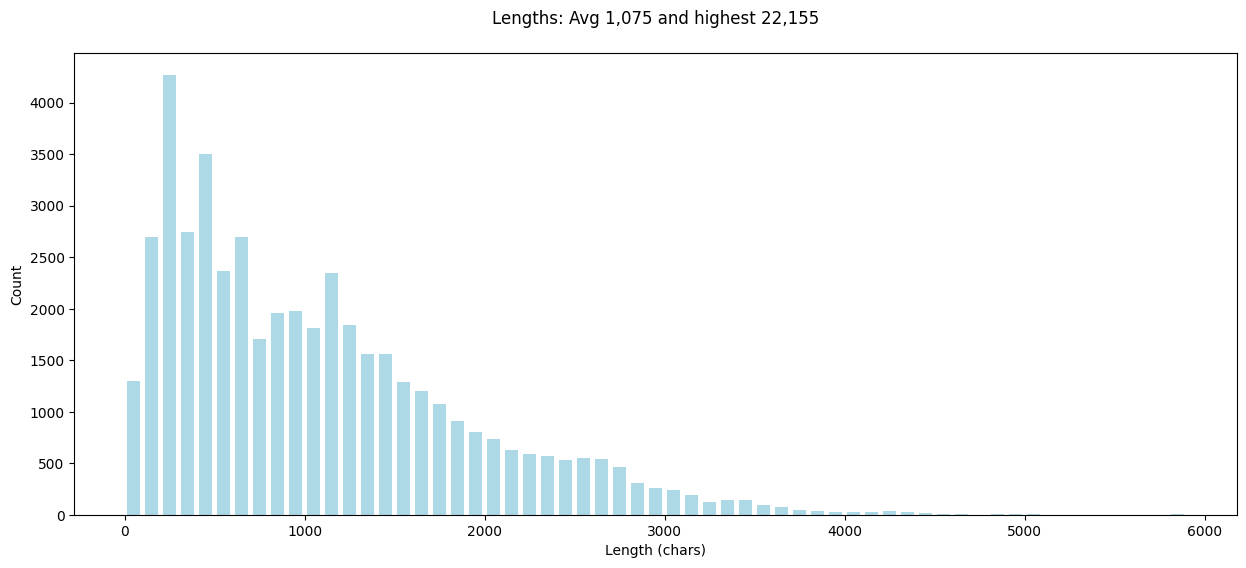

GE Dryer Drum Front Support Bearing. Front drum bearings prevent dryers from making a harsh banging sound while powered on. This particular model will fit a wide variety of GE dryers. Modern dryers are designed to dry clothes in relative silence. If your dryer is consistently making a banging sound while it is powered on, chances are the drum bearing needs to be replaced. In addition to preventing dryers from making loud noises, drum bearings also create the tumbling motion within the appliance. GE’s front drum bearing holds four glides and has the following dimensions: Height: 8 ½ “ Width: 20 ¼ “ (approx) Note that the slides are not included with the purchase of this front drum bearing. Slides with the following model numbers should be purchased to remain in line with this particular drum bearing model: WE1M333 WE1M481. Models it applies to: DBB5000EF0GG, DBB5000GF0GG, DBB5000GF1GG, DBLR333EE0CC, DBLR333EE0WW, DBLR333EE1CC, DBLR333EE1WW, DBLR333EE2CC, DBLR333EE2WW, DBLR333EG0CC, DBLR

In [ ]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

# Plot the distribution of lengths
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

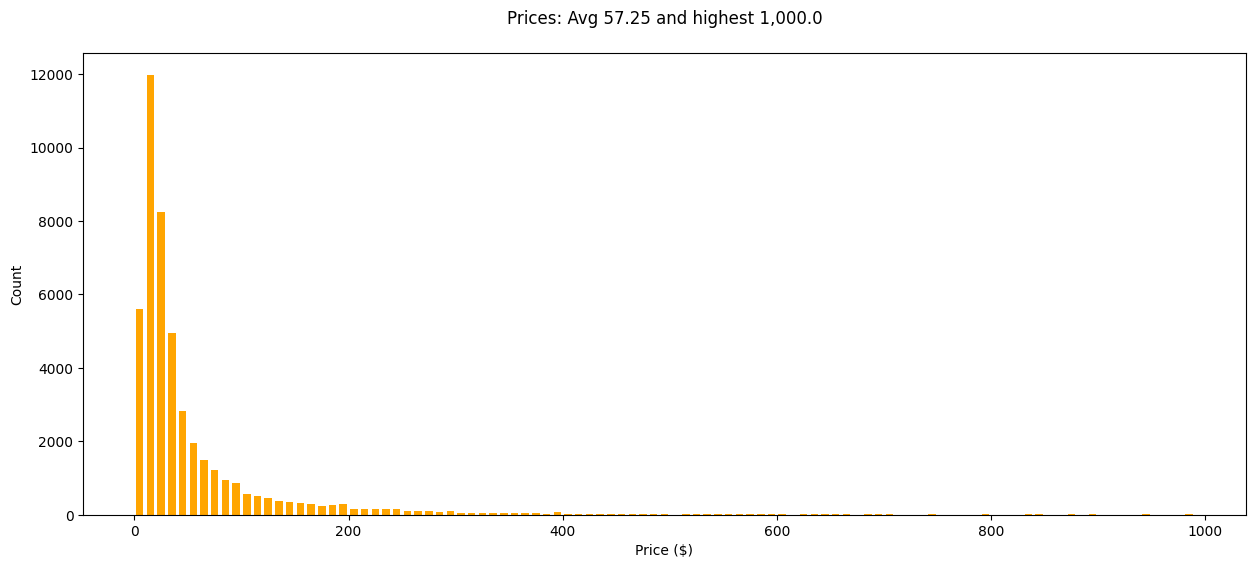

WP67003405 67003405 Door Pivot Block - Compatible Kenmore KitchenAid Maytag Whirlpool Refrigerator - Replaces AP6010352 8208254 PS11743531 - Quick DIY Repair Solution. WP67003405 Pivot Block For Vernicle Mullion Strip On Door - A high-quality exact equivalent for part numbers AP6010352, 67003405, 1025322, 12698403, 67003194, 8208254, and PS11743531. Compatibility with major brands - WP67003405 Door Guide is compatible with Whirlpool, Amana, Dacor, Gaggenau, Hardwick, Jenn-Air, Kenmore, KitchenAid, and Maytag. Quick DIY repair - WP67003405 Refrigerator Door Guide Pivot Block Replacement will help if your appliance door doesn't open or close. Wear work gloves to protect your hands during the repair process. Attentive support - If you are uncertain about whether the block fits your refrigerator, we will help. We generally put forth a valiant effort to guarantee you are totally happy with your purchase. High-quality elements - WP67003405 67003405 Pivot Block Replacement meets or exceeds al

In [ ]:
# Plot the distribution of prices
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

if len(items) > 3:
    print(items[3].full)

In [ ]:
!find "/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer" -maxdepth 2 -type f -print
!cat "/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/__init__.py" 2>/dev/null

/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/batch.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/parser.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/items.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/loaders.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/evaluator.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/preprocessor.py
/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/deep_neural_network.py


In [ ]:
!cat "/content/LLM_Engineering_opensource-main/finetuning_frontier_model/pricer/loaders.py"

from datetime import datetime
from tqdm import tqdm
from datasets import load_dataset
from concurrent.futures import ProcessPoolExecutor
from pricer.parser import parse
import os

CHUNK_SIZE = 1000

cpu_count = os.cpu_count()
WORKERS = max(cpu_count - 1, 1)


class ItemLoader:
    def __init__(self, category):
        self.category = category
        self.dataset = None

    def from_datapoint(self, datapoint):
        """
        Try to create an Item from this datapoint
        Return the Item if successful, or None if it shouldn't be included
        """
        return parse(datapoint, self.category)

    def from_chunk(self, chunk):
        """
        Create a list of Items from this chunk of elements from the Dataset
        """
        batch = [self.from_datapoint(datapoint) for datapoint in chunk]
        return [item for item in batch if item is not None]

    def chunk_generator(self):
        """
        Iterate over the Dataset, yielding chunks of datapoints at a time
     

In [ ]:
from pricer.loaders import ItemLoader

loader = ItemLoader("Appliances")
items = loader.load()

dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

print(f"A grand total of {len(items):,} items")

ModuleNotFoundError: No module named 'pricer.loaders'

In [ ]:
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

In [ ]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

In [ ]:
# Plot the distribution of prices
prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [ ]:
from collections import Counter

category_counts = Counter([item.category for item in items])
categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [ ]:
np.random.seed(42)

# FIX: SIZE was hardcoded to 820_000. If the deduplicated pool is smaller than
# that, np.random.choice(..., replace=False) raises
# "ValueError: Cannot take a larger sample than population when 'replace=False'".
# Clamp it to whatever is actually available.
SIZE = min(820_000, len(items))
print(f"Sampling {SIZE:,} items out of {len(items):,} available")

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w[categories == "Tools_and_Home_Improvement"] *= 0.5
w[categories == "Automotive"] *= 0.05

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]

prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [ ]:
# Just for good measure, let's shuffle the sample again for the final dataset
random.seed(42)
random.shuffle(sample)

prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [ ]:
from collections import Counter

category_counts = Counter([item.category for item in sample])
categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [ ]:
# For another perspective, let's look at a pie chart
plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')
plt.show()

In [ ]:
# How does the price vary with the character count?
sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation with text length?')
plt.show()

In [ ]:
# How does the price vary with the weight?
# FIX: not every item has a weight populated — plotting None values crashes
# matplotlib. Filter to (weight, price) pairs where weight is a real number.
pairs = [(item.weight, item.price) for item in sample if item.weight is not None]
skipped = len(sample) - len(pairs)
if skipped:
    print(f"Skipping {skipped:,} items with no weight recorded")

ounces = [w for w, _ in pairs]
prices = [p for _, p in pairs]

plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")
plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?')
plt.show()

In [ ]:
# FIX: replace this with YOUR Hugging Face username (the "AbhishekRavindran"
# placeholder will fail with a permissions error unless that happens to be you).
username = "YOUR_HF_USERNAME"
full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"

# FIX: split sizes are now computed from the actual sample size instead of
# hardcoded 800_000 / 810_000, which only worked when SIZE was exactly 820_000.
n = len(sample)
n_val = min(10_000, max(1, n // 20))
n_test = min(10_000, max(1, n // 20))
n_train = n - n_val - n_test

train = sample[:n_train]
val = sample[n_train:n_train + n_val]
test = sample[n_train + n_val:]

print(f"train={len(train):,}  val={len(val):,}  test={len(test):,}")

Item.push_to_hub(full, train, val, test)

n_train_lite = min(20_000, len(train))
n_val_lite = min(1_000, len(val))
n_test_lite = min(1_000, len(test))

train_lite = train[:n_train_lite]
val_lite = val[:n_val_lite]
test_lite = test[:n_test_lite]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)